# Pitch Quality — Baseline (Phase 3: EDA → cleaning → features → baseline models → validation)

**Question:** how much run value does a pitch carry from its physics alone (velo, movement, spin, release), before the result is known?

- **Data:** Statcast regular season 2020–2026, slim columns, one parquet per month in the public `statcast` Supabase bucket (built by `python -m soccerhub.pipelines.statcast --upload`).
- **Already done upstream:** deduped on `(game_pk, at_bat_number, pitch_number)`, `game_type == 'R'` only, **left-handers mirrored** (`pfx_x`, `release_pos_x`, `vx0`, `ax` negated, `spin_axis → 360 − axis`), so every pitcher reads as a righty. `plate_x` and `arm_angle` are raw.
- **Target `xrv`:** pitcher-view run value. Balls, strikes and fouls keep their actual value (`−delta_run_exp`); balls in play get the *expected* value for their xwOBA, so defense and luck don't leak into a stuff model.
- **Split:** train 2021–24 · validate 2025 · test 2026 · extra test 2020, scored separately for pitches with and without `arm_angle` (25% of 2020 is missing it).
- **The real test:** does 2025 predicted quality forecast 2026 results better than the stats an analyst already has (run value, whiff%, CSW%)? And does it get there sooner, after fewer pitches (V8)?

| Decision | Choice | Why |
|---|---|---|
| Ball-in-play value | expected RV by xwOBA bin | Stuff should not be graded on defense / BABIP luck |
| Stuff+ scale | `stuff_plus` (all pitches, one scale) + `stuff_plus_type` (within pitch type) | Pitch-mix decisions need one scale; "best changeup" needs within-type |
| 2020 | held out as a test season | 60-game season, arm_angle 25% null; tests how the model copes with missing arm angle |
| Site cutoff for run-value columns | set by split-half reliability (chart V4) | RV/100 on 25 pitches is noise |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

SUPABASE_URL = "https://rgnzemkdldohplwbxxwy.supabase.co"  # public project URL (same one the site uses)
BASE = f"{SUPABASE_URL}/storage/v1/object/public/statcast/pitches"
SEASONS = range(2020, 2027)
TRAIN, VAL, TEST, TEST_2020 = range(2021, 2025), [2025], [2026], [2020]

# Chart style: validated categorical palette (fixed order, never cycled), recessive axes, one surface
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e8e7e3"
PT_COLOR = {"FF": "#2a78d6", "SI": "#eb6834", "FC": "#1baf7a", "SL": "#eda100",
            "ST": "#e87ba4", "CU": "#008300", "CH": "#4a3aa7", "FS": "#e34948"}
BLUE, ORANGE, NEUTRAL = "#2a78d6", "#eb6834", "#898781"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True, "lines.linewidth": 2,
    "legend.frameon": False, "figure.dpi": 110,
})

## 1. Load

In [2]:
parts = []
for season in SEASONS:
    for month in range(3, 12):
        try:
            parts.append(pd.read_parquet(f"{BASE}/{season}/{month:02d}.parquet").assign(season=season))
        except Exception:  # month with no regular-season games (e.g. 2020 before July) -> no file
            pass
raw = pd.concat(parts, ignore_index=True)
raw["game_date"] = pd.to_datetime(raw.game_date)
print(f"{len(raw):,} pitches, {raw.memory_usage(deep=True).sum() / 1e9:.2f} GB in memory")
raw.groupby("season").size().rename("pitches").to_frame().T

4,548,695 pitches, 2.29 GB in memory


season,2020,2021,2022,2023,2024,2025,2026
pitches,264262,712320,710210,720684,711899,712528,716792


## 2. EDA

In [3]:
# Pitch mix by season (%)
mix = pd.crosstab(raw.season, raw.pitch_type.fillna("null"), normalize="index").mul(100).round(1)
mix[mix.mean().sort_values(ascending=False).index]

pitch_type,FF,SI,SL,CH,FC,CU,ST,FS,KC,SV,null,FA,EP,FO,CS,KN,PO,SC,UN
season,,,,,,,,,,,,,,,,,,,
2020,34.7,15.5,16.6,11.6,7.1,8.0,1.4,1.9,2.6,0.2,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,35.4,15.2,16.6,11.2,7.2,7.3,2.3,1.6,2.3,0.4,0.4,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022,33.1,15.4,16.2,11.1,7.4,7.3,4.5,1.6,2.3,0.5,0.3,0.2,0.1,0.0,0.0,0.0,0.0,0.0,0.0
2023,31.9,15.4,15.6,10.8,7.8,6.5,6.4,2.2,2.0,0.4,0.4,0.2,0.1,0.1,0.0,0.0,0.0,0.0,0.0
2024,31.7,15.7,14.7,10.2,8.1,6.1,7.3,3.1,1.7,0.5,0.4,0.1,0.1,0.0,0.0,0.1,0.0,0.0,0.0
2025,31.8,15.4,14.4,10.3,7.4,6.7,7.6,3.3,1.8,0.5,0.4,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0
2026,30.6,16.6,13.1,11.1,8.0,6.4,8.3,3.2,1.5,0.4,0.4,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0


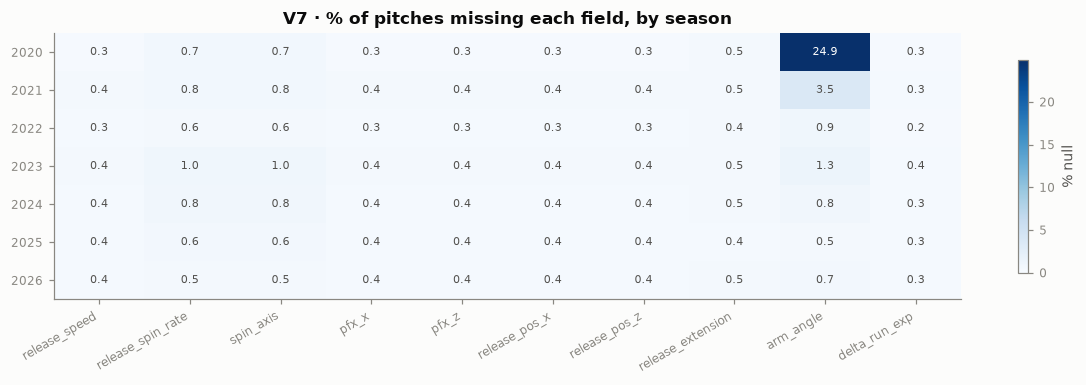

In [4]:
# V7 — null rate by season x column. arm_angle in 2020 is the outlier that drove the 2020 decision.
PHYS = ["release_speed", "release_spin_rate", "spin_axis", "pfx_x", "pfx_z", "release_pos_x",
        "release_pos_z", "release_extension", "arm_angle", "delta_run_exp", "estimated_woba_using_speedangle"]
nulls = raw.groupby("season")[PHYS].apply(lambda d: d.isna().mean().mul(100))
nulls_phys = nulls.drop(columns="estimated_woba_using_speedangle")  # xwOBA is null by design except balls in play

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(nulls_phys.values, cmap="Blues", vmin=0, vmax=max(5, nulls_phys.values.max()), aspect="auto")
ax.set_xticks(range(nulls_phys.shape[1]), nulls_phys.columns, rotation=30, ha="right")
ax.set_yticks(range(len(nulls_phys)), nulls_phys.index)
ax.grid(False)
for i in range(nulls_phys.shape[0]):
    for j in range(nulls_phys.shape[1]):
        v = nulls_phys.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7, color="white" if v > 12 else INK2)
ax.set_title("V7 · % of pitches missing each field, by season")
fig.colorbar(im, ax=ax, label="% null", shrink=0.8)
plt.tight_layout(); plt.show()

In [5]:
# Physics by pitch type (inches of break; hb + = arm side after the LHP mirror)
view = raw.assign(ivb_in=raw.pfx_z * 12, hb_arm_in=-raw.pfx_x * 12)
main_types = raw.pitch_type.value_counts().index[:10]
view[view.pitch_type.isin(main_types)].groupby("pitch_type")[
    ["release_speed", "release_spin_rate", "ivb_in", "hb_arm_in", "spin_axis", "arm_angle"]].median().round(1)

,release_speed,release_spin_rate,ivb_in,hb_arm_in,spin_axis,arm_angle
pitch_type,,,,,,
CH,85.699997,1750.0,5.600000,14.5,238.0,37.900002
CU,79.500000,2555.0,-10.400000,-9.2,41.0,45.299999
FC,89.099998,2383.0,7.900000,-2.5,189.0,40.500000
FF,94.199997,2298.0,16.200001,7.7,213.0,41.400002
FS,86.300003,1385.0,3.200000,11.4,236.0,39.799999
KC,81.800003,2505.0,-10.300000,-6.7,36.0,43.400002
SI,93.500000,2157.0,8.400000,15.4,223.0,35.500000
SL,85.900002,2413.0,1.800000,-4.2,104.0,40.400002
ST,82.300003,2572.0,1.000000,-13.9,63.0,31.900000


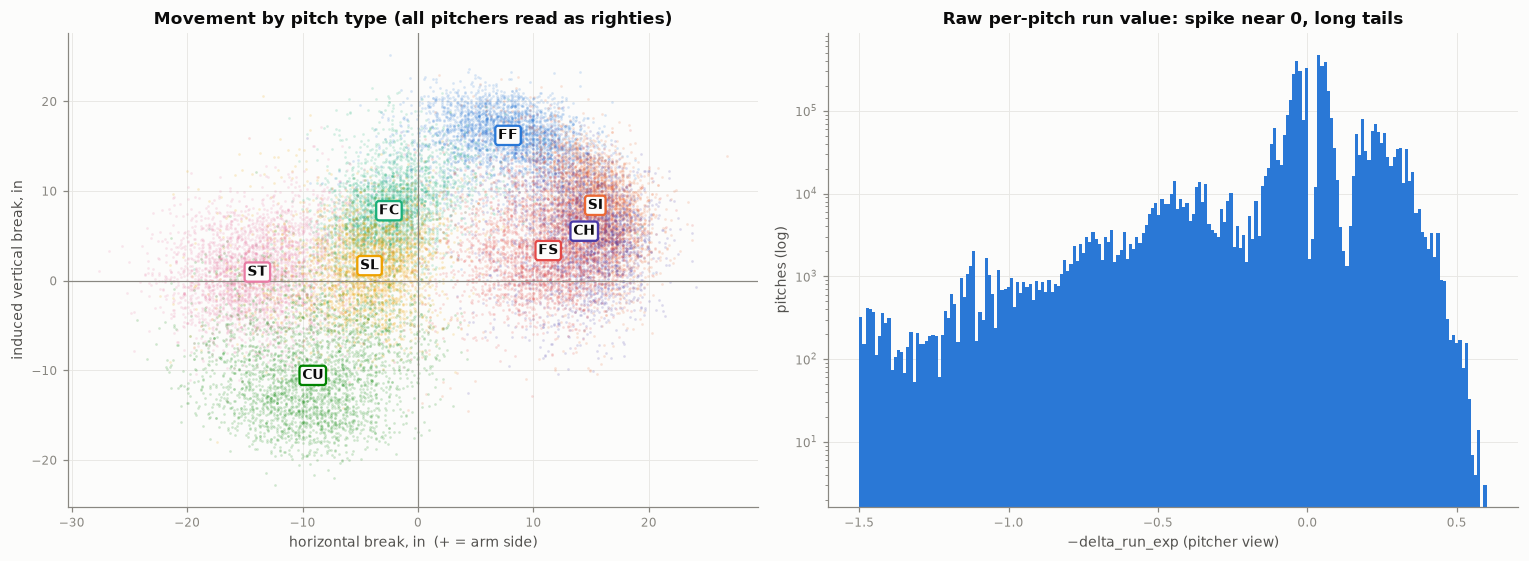

share of |rv| < 0.1: 0.709


In [6]:
# Movement sanity check: every pitch type should sit in its textbook region (direct labels, not color alone)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
for t, c in PT_COLOR.items():
    d = view[view.pitch_type == t].sample(min(3000, (view.pitch_type == t).sum()), random_state=0)
    ax[0].scatter(d.hb_arm_in, d.ivb_in, s=3, alpha=.18, color=c, linewidths=0)
    ax[0].annotate(t, (d.hb_arm_in.median(), d.ivb_in.median()), fontsize=9, fontweight="bold", color=INK,
                   ha="center", va="center", bbox=dict(boxstyle="round,pad=0.2", fc=SURFACE, ec=c, lw=1.5))
ax[0].axhline(0, color=MUTED, lw=0.8); ax[0].axvline(0, color=MUTED, lw=0.8)
ax[0].set(xlabel="horizontal break, in  (+ = arm side)", ylabel="induced vertical break, in",
          title="Movement by pitch type (all pitchers read as righties)")
ax[1].hist(-raw.delta_run_exp.dropna(), bins=200, range=(-1.5, 0.6), color=BLUE)
ax[1].set(yscale="log", xlabel="−delta_run_exp (pitcher view)", ylabel="pitches (log)",
          title="Raw per-pitch run value: spike near 0, long tails")
plt.tight_layout(); plt.show()
rv = -raw.delta_run_exp
print("share of |rv| < 0.1:", round((rv.abs() < 0.1).mean(), 3))

## 3. Cleaning

| Rule | Why |
|---|---|
| Drop null target (`automatic_ball/strike`, pitch-clock violations) | No pitch was thrown |
| Drop null core physics | Model can't score the pitch |
| Drop `pitch_type` ∈ PO, IN, EP, FA, UN, AB, CS, null | Pickoffs, intentional balls, eephus / position-player lobs, unknown |
| Drop position players pitching | Pitcher-seasons with EP+FA share > 50%, or < 100 pitches with fastball velo < 85 |
| Merge rare types SV→CU, FO→FS, SC→CH; drop anything else < 0.5% share | Too few pitches to learn a type |

`arm_angle` is **not** a core field: its nulls stay, so 2020 pitches without it can be scored separately.

In [7]:
df = raw.copy()
n0 = len(df)
log = {}

df = df[df.delta_run_exp.notna()]; log["null target"] = n0 - len(df); n = len(df)
CORE = ["release_speed", "release_spin_rate", "spin_axis", "pfx_x", "pfx_z", "release_pos_x", "release_pos_z", "release_extension"]
df = df.dropna(subset=CORE); log["null core physics"] = n - len(df); n = len(df)

# position players: computed on the pitch types before junk types are dropped
ps = raw.groupby(["season", "pitcher"]).agg(
    pitches=("pitch_type", "size"),
    junk=("pitch_type", lambda s: s.isin(["EP", "FA"]).mean()),
    fb_velo=("release_speed", lambda s: s[raw.loc[s.index, "pitch_type"].isin(["FF", "SI"])].mean()))
position = ps[(ps.junk > 0.5) | ((ps.pitches < 100) & (ps.fb_velo.fillna(0) < 85))].index
df = df[~df.set_index(["season", "pitcher"]).index.isin(position)]; log["position players"] = n - len(df); n = len(df)

df = df[~df.pitch_type.isin(["PO", "IN", "EP", "FA", "UN", "AB", "CS"]) & df.pitch_type.notna()]
log["junk pitch types"] = n - len(df); n = len(df)

df["pitch_type"] = df.pitch_type.replace({"SV": "CU", "FO": "FS", "SC": "CH"})
share = df.pitch_type.value_counts(normalize=True)
df = df[df.pitch_type.isin(share[share >= 0.005].index)]; log["rare types"] = n - len(df)
df = df.reset_index(drop=True)

print(pd.Series(log).to_string(), f"\nkept {len(df):,} / {n0:,} ({len(df) / n0:.1%})")
print(sorted(df.pitch_type.unique()))

null target          14729
null core physics    19750
position players     11175
junk pitch types      1335
rare types            1583 
kept 4,500,123 / 4,548,695 (98.9%)
['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST']


## 4. Target `xrv` — expected run value

Balls in play: replace the actual run value with the mean run value of all **training** balls in play in the same
xwOBA bin (50 quantile bins). A 105 mph lineout and a 60 mph bloop single are no longer opposite outcomes.
Everything else (balls, called/swinging strikes, fouls, HBP) keeps its actual value — those are already "true" pitch outcomes.

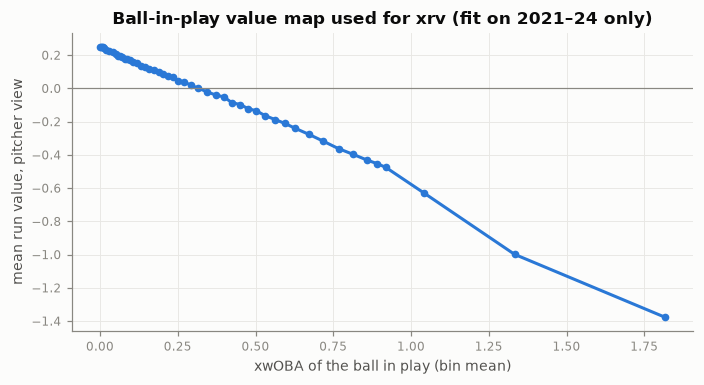

in-play pitches re-valued: 17.2% | std rv: 0.2255 → std xrv: 0.1608


In [8]:
df["rv"] = (-df.delta_run_exp).astype("float32")  # actual, pitcher view
tr, va, te, t20 = (df.season.isin(s) for s in (TRAIN, VAL, TEST, TEST_2020))

in_play = (df.description == "hit_into_play") & df.estimated_woba_using_speedangle.notna()
edges = np.unique(df.loc[tr & in_play, "estimated_woba_using_speedangle"].quantile(np.linspace(0, 1, 51)).values)
edges[0], edges[-1] = -np.inf, np.inf
bin_id = pd.cut(df.estimated_woba_using_speedangle, edges, labels=False)
bin_rv = df.loc[tr & in_play].groupby(bin_id[tr & in_play]).rv.mean()
df["xrv"] = df.rv
df.loc[in_play, "xrv"] = bin_id[in_play].map(bin_rv).astype("float32")

b = df.loc[tr & in_play].assign(bin=bin_id).groupby("bin").agg(xwoba=("estimated_woba_using_speedangle", "mean"), rv=("rv", "mean"))
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(b.xwoba, b.rv, marker="o", ms=4, color=BLUE)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set(xlabel="xwOBA of the ball in play (bin mean)", ylabel="mean run value, pitcher view",
       title="Ball-in-play value map used for xrv (fit on 2021–24 only)")
plt.tight_layout(); plt.show()
print("in-play pitches re-valued:", f"{in_play.mean():.1%}", "| std rv:", round(df.rv.std(), 4), "→ std xrv:", round(df.xrv.std(), 4))

## 5. Features

- **Raw physics:** velo, spin, spin axis (as sin/cos — it's an angle), IVB, HB, release x/z, extension, arm angle.
- **Fastball differentials:** each pitch vs the pitcher's primary fastball (most-used FF/SI that season): Δvelo, ΔIVB, ΔHB.
- **Context:** `pitch_type` one-hot, same-hand flag (`p_throws == stand`).
- **Left out:** count and location — this is a *stuff* model. Location and count belong to a later Pitching+ variant.

In [9]:
df["ivb_in"], df["hb_arm_in"] = df.pfx_z * 12, -df.pfx_x * 12
rad = np.deg2rad(df.spin_axis)
df["axis_sin"], df["axis_cos"] = np.sin(rad), np.cos(rad)
df["same_hand"] = (df.p_throws == df.stand).astype(int)

fb = df[df.pitch_type.isin(["FF", "SI"])]
primary = (fb.groupby(["season", "pitcher", "pitch_type"]).size().rename("n").reset_index()
             .sort_values("n").drop_duplicates(["season", "pitcher"], keep="last"))
fb_stats = (fb.merge(primary[["season", "pitcher", "pitch_type"]])
              .groupby(["season", "pitcher"])[["release_speed", "ivb_in", "hb_arm_in"]].mean()
              .add_prefix("fb_").reset_index())
df = df.merge(fb_stats, on=["season", "pitcher"], how="left")
df["d_velo"] = df.release_speed - df.fb_release_speed
df["d_ivb"] = df.ivb_in - df.fb_ivb_in
df["d_hb"] = df.hb_arm_in - df.fb_hb_arm_in
print("no primary fastball:", f"{df.fb_release_speed.isna().mean():.2%} of pitches")

NUM = ["release_speed", "release_spin_rate", "axis_sin", "axis_cos", "ivb_in", "hb_arm_in",
       "release_pos_x", "release_pos_z", "release_extension", "arm_angle", "d_velo", "d_ivb", "d_hb", "same_hand"]
X = pd.concat([df[NUM].astype("float32"), pd.get_dummies(df.pitch_type, prefix="pt", dtype="float32")], axis=1)
y = df.xrv
FEATS = list(X.columns)

tr, va, te, t20 = (df.season.isin(s) for s in (TRAIN, VAL, TEST, TEST_2020))
arm = df.arm_angle.notna()
SPLITS = {"val 2025": va, "test 2026": te, "2020 · arm angle": t20 & arm, "2020 · no arm angle": t20 & ~arm}
print({k: f"{m.sum():,}" for k, m in [("train 2021-24", tr)] + list(SPLITS.items())})

no primary fastball: 0.16% of pitches


{'train 2021-24': '2,823,600', 'val 2025': '705,354', 'test 2026': '709,921', '2020 · arm angle': '197,156', '2020 · no arm angle': '64,092'}


## 6. Models: type-mean baseline → Ridge → XGBoost (target `xrv`)

In [10]:
XGB = dict(learning_rate=0.03, max_depth=6, min_child_weight=200, subsample=0.8, colsample_bytree=0.8, tree_method="hist")

def per_pitch(name, predict):
    rows = []
    for split, m in SPLITS.items():
        p = predict(m)
        rows.append({"model": name, "split": split, "rmse": float(np.sqrt(mean_squared_error(y[m], p))), "r2": r2_score(y[m], p)})
    return rows

results = []
type_mean = y[tr].groupby(df.pitch_type[tr]).mean()
results += per_pitch("type mean", lambda m: df.pitch_type[m].map(type_mean).fillna(y[tr].mean()).values)

ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=10.0)).fit(X[tr], y[tr])
results += per_pitch("ridge", lambda m: ridge.predict(X[m]))

booster = xgb.XGBRegressor(n_estimators=2000, early_stopping_rounds=100, eval_metric="rmse", **XGB)
booster.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], verbose=200)
results += per_pitch("xgboost", lambda m: booster.predict(X[m]))

df["pred"] = booster.predict(X)
df["pred_ridge"] = ridge.predict(X)
pd.DataFrame(results).pivot(index="model", columns="split", values="r2").round(5)

[0]	validation_0-rmse:0.15983


[200]	validation_0-rmse:0.15965


[400]	validation_0-rmse:0.15964


[440]	validation_0-rmse:0.15964


split,2020 · arm angle,2020 · no arm angle,test 2026,val 2025
model,,,,
ridge,0.00103,0.00117,0.00082,0.00073
type mean,0.00068,0.00088,0.00015,0.00029
xgboost,0.00278,0.00271,0.00261,0.00238


Per-pitch R² stays small even with `xrv`: one pitch's outcome is still mostly a ball/strike coin flip.
The 2020 columns answer the arm-angle question: if **no arm angle** scores close to **arm angle**, XGBoost
degrades gracefully when the field is missing.

In [11]:
# Same features, grouped by pitcher: no pitcher appears in both train and test folds (2024 only, for speed)
sub = df.season == 2024
gkf_r2 = []
for f_tr, f_te in GroupKFold(n_splits=5).split(X[sub], y[sub], groups=df.pitcher[sub]):
    m = xgb.XGBRegressor(n_estimators=booster.best_iteration + 1, **XGB)
    m.fit(X[sub].iloc[f_tr], y[sub].iloc[f_tr])
    gkf_r2.append(r2_score(y[sub].iloc[f_te], m.predict(X[sub].iloc[f_te])))
print("GroupKFold-by-pitcher R² (2024):", np.round(gkf_r2, 4), "mean", round(np.mean(gkf_r2), 4))

GroupKFold-by-pitcher R² (2024): [0.0025 0.0014 0.0021 0.0018 0.0013] mean 0.0018


In [12]:
# Comparison models for V3: does anything simpler match the full model at forecasting next year?
# (a) velo + pitch type only  (b) same XGBoost trained on the ACTUAL rv target (the decision we replaced)
VELO = ["release_speed"] + [c for c in FEATS if c.startswith("pt_")]
Xv = X[VELO].copy()
for c in VELO[1:]:
    Xv[c + "_x_velo"] = Xv[c] * Xv.release_speed  # velo slope per pitch type
velo_only = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xv[tr], y[tr])
df["pred_velo"] = velo_only.predict(Xv)

booster_actual = xgb.XGBRegressor(n_estimators=2000, early_stopping_rounds=100, eval_metric="rmse", **XGB)
booster_actual.fit(X[tr], df.rv[tr], eval_set=[(X[va], df.rv[va])], verbose=False)
df["pred_actual_target"] = booster_actual.predict(X)
print("XGB best iteration — xrv target:", booster.best_iteration, "| actual target:", booster_actual.best_iteration)

XGB best iteration — xrv target: 340 | actual target: 211


## 7. Evaluation and validation charts

Stuff is a pitcher-pitch-type property, so everything below aggregates to **season × pitcher × pitch_type**, per 100 pitches.

In [13]:
MIN_N = 100
WHIFF = ["swinging_strike", "swinging_strike_blocked", "foul_tip"]
df["is_whiff"] = df.description.isin(WHIFF).astype("float32")
df["is_csw"] = df.description.isin(WHIFF + ["called_strike"]).astype("float32")  # called + swinging strikes
PRED_COLS = {"pred": "XGBoost (xrv)", "pred_actual_target": "XGBoost (actual rv)", "pred_ridge": "Ridge (xrv)", "pred_velo": "Velo + type"}
agg = (df.groupby(["season", "pitcher", "pitch_type"])
         .agg(n=("rv", "size"), actual=("rv", "mean"), xactual=("xrv", "mean"),
              velo=("release_speed", "mean"), ivb=("ivb_in", "mean"),
              whiff=("is_whiff", "mean"), csw=("is_csw", "mean"),
              **{c: (c, "mean") for c in PRED_COLS})
         .reset_index())
for c in ["actual", "xactual", *PRED_COLS]:
    agg[c] *= 100  # per 100 pitches
agg = agg[agg.n >= MIN_N].copy()

# Stuff+: two scales. stuff_plus = one scale for all pitches in the season; stuff_plus_type = within pitch type.
z = lambda s: (s - s.mean()) / s.std()
agg["stuff_plus"] = 100 + 10 * agg.groupby("season").pred.transform(z)
agg["stuff_plus_type"] = 100 + 10 * agg.groupby(["season", "pitch_type"]).pred.transform(z)

pairs = agg[agg.season == 2025].merge(agg[agg.season == 2026], on=["pitcher", "pitch_type"], suffixes=("_25", "_26"))
print(f"{len(pairs)} pitcher-pitch types with >= {MIN_N} pitches in both 2025 and 2026")

1245 pitcher-pitch types with >= 100 pitches in both 2025 and 2026


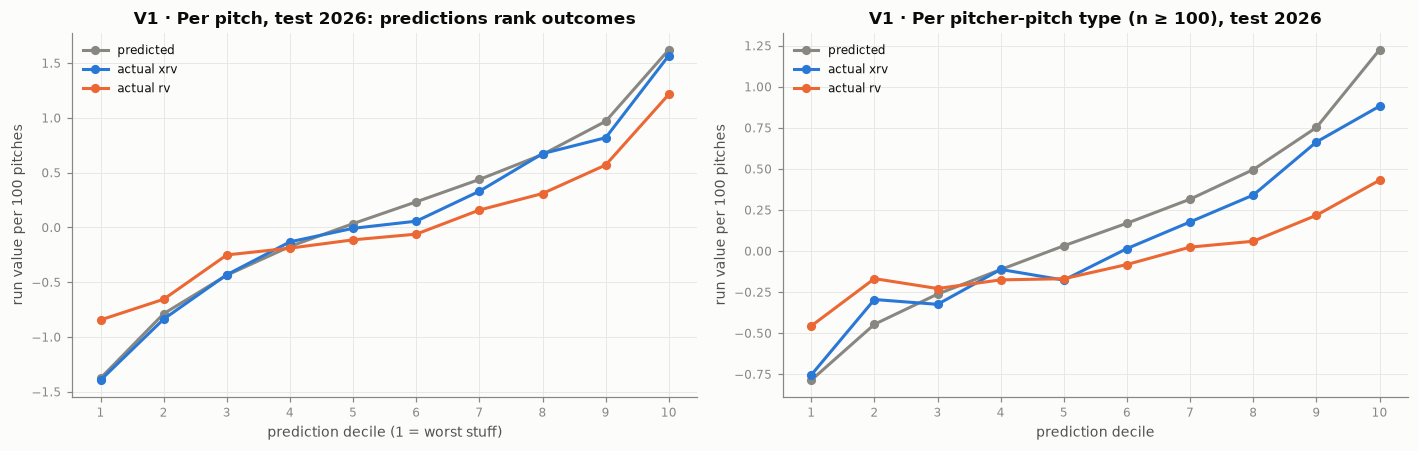

In [14]:
# V1 — calibration on test 2026: do higher predictions really mean better pitches?
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=False)
t = df[te].assign(decile=lambda d: pd.qcut(d.pred, 10, labels=False))
cal = t.groupby("decile").agg(pred=("pred", "mean"), xrv=("xrv", "mean"), rv=("rv", "mean")) * 100
ax[0].plot(cal.index + 1, cal.pred, marker="o", ms=5, color=NEUTRAL, label="predicted")
ax[0].plot(cal.index + 1, cal.xrv, marker="o", ms=5, color=BLUE, label="actual xrv")
ax[0].plot(cal.index + 1, cal.rv, marker="o", ms=5, color=ORANGE, label="actual rv")
ax[0].set(xlabel="prediction decile (1 = worst stuff)", ylabel="run value per 100 pitches",
          title="V1 · Per pitch, test 2026: predictions rank outcomes")
ax[0].set_xticks(range(1, 11)); ax[0].legend()

a = agg[agg.season == 2026].assign(decile=lambda d: pd.qcut(d.pred, 10, labels=False))
cal2 = a.groupby("decile")[["pred", "xactual", "actual"]].mean()
ax[1].plot(cal2.index + 1, cal2.pred, marker="o", ms=5, color=NEUTRAL, label="predicted")
ax[1].plot(cal2.index + 1, cal2.xactual, marker="o", ms=5, color=BLUE, label="actual xrv")
ax[1].plot(cal2.index + 1, cal2.actual, marker="o", ms=5, color=ORANGE, label="actual rv")
ax[1].set(xlabel="prediction decile", ylabel="run value per 100 pitches",
          title=f"V1 · Per pitcher-pitch type (n ≥ {MIN_N}), test 2026")
ax[1].set_xticks(range(1, 11)); ax[1].legend()
plt.tight_layout(); plt.show()

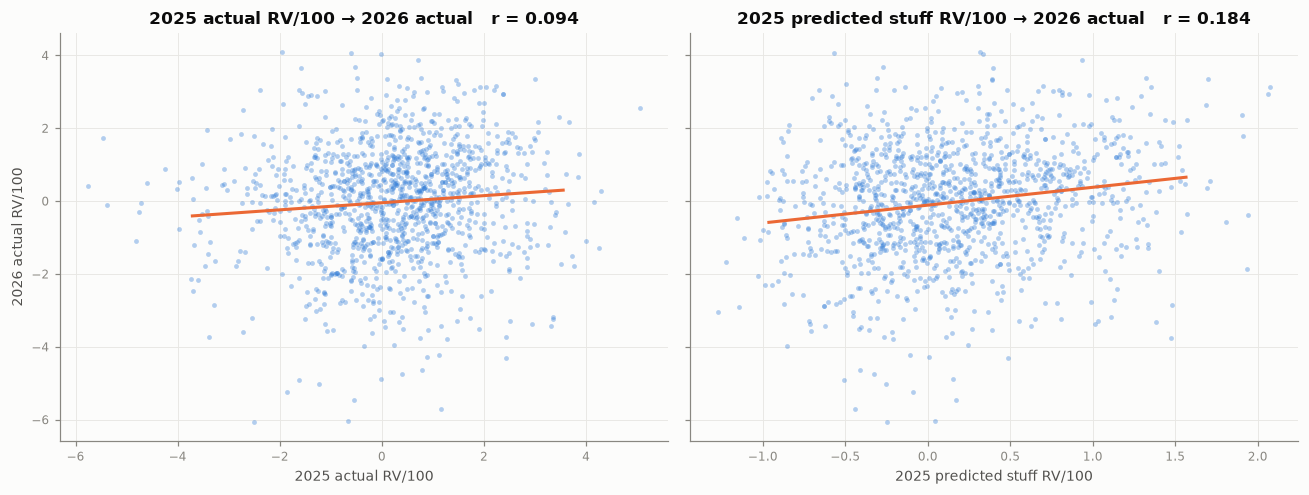

In [15]:
# V2 — the headline: 2025 stuff vs 2025 results as forecasts of 2026 results (same y-axis, same scale)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for a_, x, label in [(ax[0], "actual_25", "2025 actual RV/100"), (ax[1], "pred_25", "2025 predicted stuff RV/100")]:
    r = pairs[x].corr(pairs.actual_26)
    a_.scatter(pairs[x], pairs.actual_26, s=10, alpha=.35, color=BLUE, linewidths=0)
    m, c = np.polyfit(pairs[x], pairs.actual_26, 1)
    xs = np.linspace(pairs[x].quantile(.01), pairs[x].quantile(.99), 50)
    a_.plot(xs, m * xs + c, color=ORANGE)
    a_.set(xlabel=label, title=f"{label} → 2026 actual   r = {r:.3f}")
ax[0].set_ylabel("2026 actual RV/100")
plt.tight_layout(); plt.show()

XGBoost (xrv) minus CSW%: -0.002  95% CI [-0.066, +0.061]
actual-rv target minus xrv target: +0.028  95% CI [-0.004, +0.060]


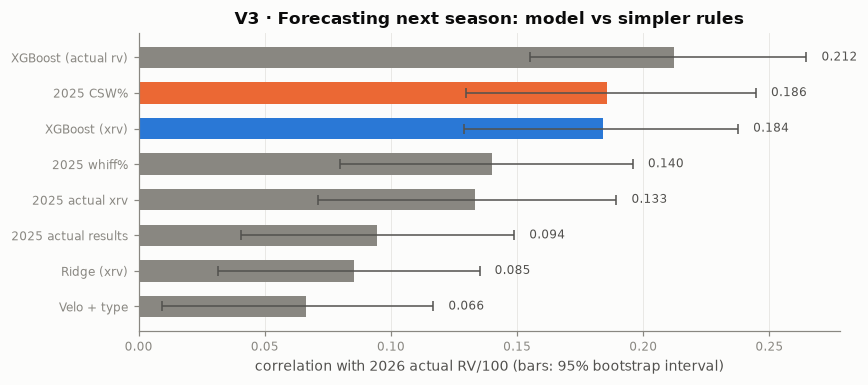

stuff year-over-year (XGBoost xrv): 0.921


In [16]:
# V3 — which forecast of 2026 actual RV/100 is best? Bars sorted, value labels on each bar.
# Baselines an analyst would reach for first: last year's run value, whiff% and CSW% (one line of pandas each)
fc = {"2025 actual results": pairs.actual_25.corr(pairs.actual_26),
      "2025 actual xrv": pairs.xactual_25.corr(pairs.actual_26),
      "2025 whiff%": pairs.whiff_25.corr(pairs.actual_26),
      "2025 CSW%": pairs.csw_25.corr(pairs.actual_26)}
fc.update({lab: pairs[f"{c}_25"].corr(pairs.actual_26) for c, lab in PRED_COLS.items()})
fc = pd.Series(fc).sort_values()
# 95% bootstrap interval: resample the same pitcher-pitch types for every forecast so intervals are comparable
src = {"2025 actual results": "actual_25", "2025 actual xrv": "xactual_25", "2025 whiff%": "whiff_25", "2025 CSW%": "csw_25", **{lab: f"{c}_25" for c, lab in PRED_COLS.items()}}
y26 = pairs.actual_26.values
rng = np.random.default_rng(0)
idx = [rng.integers(0, len(pairs), len(pairs)) for _ in range(1000)]
boot = {k: np.array([np.corrcoef(pairs[src[k]].values[i], y26[i])[0, 1] for i in idx]) for k in fc.index}
lo = [np.percentile(boot[k], 2.5) for k in fc.index]
hi = [np.percentile(boot[k], 97.5) for k in fc.index]
diff = boot["XGBoost (actual rv)"] - boot["XGBoost (xrv)"]  # paired: same resamples
d = boot["XGBoost (xrv)"] - boot["2025 CSW%"]
print(f"XGBoost (xrv) minus CSW%: {d.mean():+.3f}  95% CI [{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]")
print(f"actual-rv target minus xrv target: {diff.mean():+.3f}  95% CI [{np.percentile(diff, 2.5):+.3f}, {np.percentile(diff, 97.5):+.3f}]")
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [BLUE if k == "XGBoost (xrv)" else ORANGE if k == "2025 CSW%" else NEUTRAL for k in fc.index]
ax.barh(fc.index, fc.values, color=colors, height=0.6)
ax.errorbar(fc.values, range(len(fc)), xerr=[fc.values - lo, np.array(hi) - fc.values], fmt="none", ecolor=INK2, elinewidth=1, capsize=3)
for i, v in enumerate(fc.values):
    ax.text(hi[i] + 0.006, i, f"{v:.3f}", va="center", fontsize=8, color=INK2)
ax.set(xlabel="correlation with 2026 actual RV/100 (bars: 95% bootstrap interval)",
       title="V3 · Forecasting next season: model vs simpler rules")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("stuff year-over-year (XGBoost xrv):", round(pairs.pred_25.corr(pairs.pred_26), 3))

### V3b · Rolling check: xrv vs actual-rv target across four season pairs

One season pair can't separate the two targets (V3 interval crosses zero). For each pair N → N+1, train on
2021…N−1 only (the xrv value map is refit on the same seasons), predict season N, and correlate the
pitcher-pitch-type means with season N+1 actual RV/100. Tree count is fixed at each target's early-stopping
best from section 6, so no fold peeks at its own forecast season.

2022 done


2023 done


2024 done


2025 done


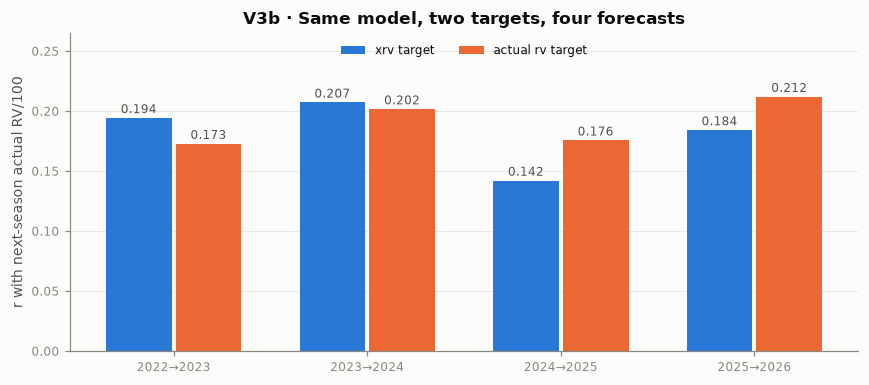

target     actual rv    xrv  actual − xrv
pair                                     
2022→2023      0.173  0.194        -0.021
2023→2024      0.202  0.207        -0.006
2024→2025      0.176  0.142         0.034
2025→2026      0.212  0.184         0.028

mean difference (actual − xrv): +0.009; actual wins 2 of 4 pairs


In [17]:
def xrv_for(train_mask):
    """xrv with the in-play value map fit on train_mask only."""
    e = np.unique(df.loc[train_mask & in_play, "estimated_woba_using_speedangle"].quantile(np.linspace(0, 1, 51)).values)
    e[0], e[-1] = -np.inf, np.inf
    b_id = pd.cut(df.estimated_woba_using_speedangle, e, labels=False)
    out = df.rv.copy()
    out[in_play] = b_id[in_play].map(df.loc[train_mask & in_play].groupby(b_id[train_mask & in_play]).rv.mean()).astype("float32")
    return out

in_play = (df.description == "hit_into_play") & df.estimated_woba_using_speedangle.notna()  # df was re-indexed by the merge
rolling = []
for n in [2022, 2023, 2024, 2025]:
    fold_tr = df.season.between(2021, n - 1)
    scored = df.season == n
    targets = {"xrv": (xrv_for(fold_tr), booster.best_iteration + 1),
               "actual rv": (df.rv, booster_actual.best_iteration + 1)}
    for name, (target, trees) in targets.items():
        m = xgb.XGBRegressor(n_estimators=trees, **XGB).fit(X[fold_tr], target[fold_tr])
        g = (df[scored].assign(p=m.predict(X[scored])).groupby(["pitcher", "pitch_type"])
               .agg(n=("p", "size"), stuff=("p", "mean")).query("n >= @MIN_N"))
        nxt = (df[df.season == n + 1].groupby(["pitcher", "pitch_type"])
                 .agg(n=("rv", "size"), actual=("rv", "mean")).query("n >= @MIN_N"))
        j = g.join(nxt, how="inner", lsuffix="_n")
        rolling.append({"pair": f"{n}→{n + 1}", "target": name, "pairs": len(j), "r": j.stuff.corr(j.actual)})
    print(n, "done", flush=True)

roll = pd.DataFrame(rolling).pivot(index="pair", columns="target", values="r")
roll["actual − xrv"] = roll["actual rv"] - roll["xrv"]

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(roll))
for k, (t, c) in enumerate([("xrv", BLUE), ("actual rv", ORANGE)]):
    ax.bar(x + (k - 0.5) * 0.36, roll[t], width=0.34, color=c, label=f"{t} target")
    for xi, v in zip(x, roll[t]):
        ax.text(xi + (k - 0.5) * 0.36, v + 0.004, f"{v:.3f}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(x, roll.index)
ax.set(ylabel="r with next-season actual RV/100", title="V3b · Same model, two targets, four forecasts")
ax.set_ylim(0, roll[["xrv", "actual rv"]].values.max() * 1.25)
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.0)); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print(roll.round(3).to_string())
print(f"\nmean difference (actual − xrv): {roll['actual − xrv'].mean():+.3f}; actual wins {int((roll['actual − xrv'] > 0).sum())} of {len(roll)} pairs")

### V8 · The early read: what does each metric say after the first 25 / 50 / 100 / 200 pitches?

Over a full season, CSW% forecasts as well as the model (V3). Stuff's claimed edge is speed: it needs physics only,
not results. Test it directly on 2026 (never trained on): take each pitcher-pitch type's **first k pitches** of the
season, compute each metric on them, and correlate with the **rest of the season's** actual RV/100. Every metric is
scored on the same pitcher-pitch types (≥ 100 pitches left after the first k).

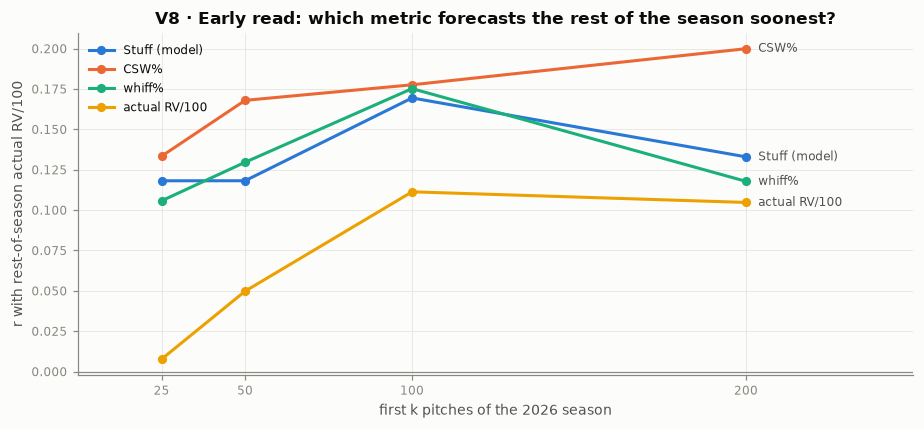

,groups,stuff,csw,whiff,rv
first k pitches,,,,,
25,1751,0.118,0.133,0.106,0.008
50,1553,0.118,0.168,0.130,0.050
100,1235,0.169,0.178,0.175,0.111
200,811,0.133,0.200,0.118,0.105


In [18]:
REST_MIN = 100
KEYS = ["pitcher", "pitch_type"]
s26 = df[te].sort_values(["game_date", "game_pk", "at_bat_number", "pitch_number"]).copy()
s26["k"] = s26.groupby(KEYS).cumcount()
s26["total"] = s26.groupby(KEYS).rv.transform("size")
EARLY = {"stuff": "Stuff (model)", "csw": "CSW%", "whiff": "whiff%", "rv": "actual RV/100"}
rows = []
for k in [25, 50, 100, 200]:
    pool = s26[s26.total >= k + REST_MIN]
    early = pool[pool.k < k].groupby(KEYS).agg(stuff=("pred", "mean"), csw=("is_csw", "mean"),
                                                whiff=("is_whiff", "mean"), rv=("rv", "mean"))
    rest = pool[pool.k >= k].groupby(KEYS).rv.mean().rename("rest_rv")
    j = early.join(rest)
    rows.append({"first k pitches": k, "groups": len(j), **{m: j[m].corr(j.rest_rv) for m in EARLY}})
early_read = pd.DataFrame(rows).set_index("first k pitches")

fig, ax = plt.subplots(figsize=(8.5, 4))
for (m, lab), c in zip(EARLY.items(), [BLUE, ORANGE, "#1baf7a", "#eda100"]):
    ax.plot(early_read.index, early_read[m], marker="o", ms=5, color=c, label=lab)
    ax.annotate(lab, (early_read.index[-1], early_read[m].iloc[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK2)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xticks(early_read.index)
ax.set(xlabel="first k pitches of the 2026 season", ylabel="r with rest-of-season actual RV/100", xlim=(0, 250),
       title="V8 · Early read: which metric forecasts the rest of the season soonest?")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
early_read.round(3)

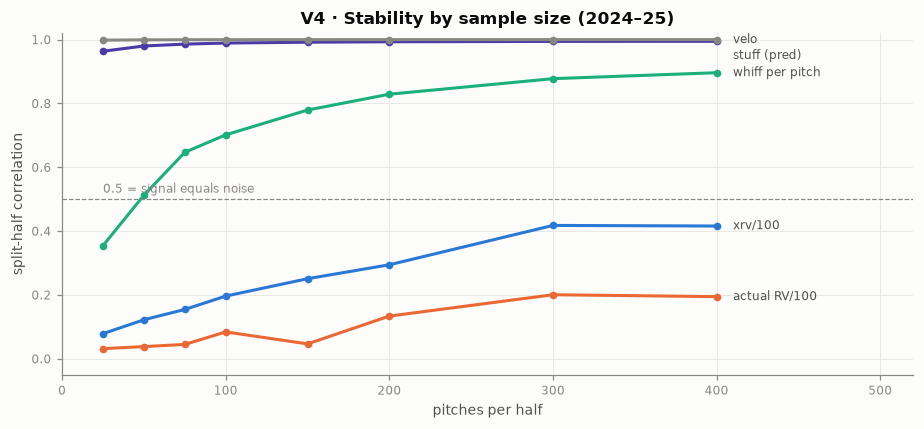

,groups,rv,xrv,whiff,pred,release_speed
n,,,,,,
25,4903,0.032,0.079,0.354,0.963,0.998
50,3796,0.038,0.122,0.512,0.980,0.999
75,3008,0.045,0.154,0.647,0.986,0.999
100,2461,0.084,0.196,0.701,0.989,1.000
150,1613,0.046,0.251,0.779,0.992,1.000
200,1052,0.134,0.294,0.829,0.993,1.000
300,477,0.200,0.418,0.877,0.994,1.000
400,222,0.195,0.416,0.896,0.994,1.000


In [19]:
# V4 — how many pitches until each number is trustworthy? Split-half reliability on 2024-25.
# For each n: pitcher-pitch types with >= 2n pitches, draw 2n at random, split in halves, correlate the halves.
rng = np.random.default_rng(0)
pool = df[df.season.isin([2024, 2025])].assign(whiff=lambda d: d.description.isin(["swinging_strike", "swinging_strike_blocked", "foul_tip"]).astype(float))
METRICS = {"rv": "actual RV/100", "xrv": "xrv/100", "whiff": "whiff per pitch", "pred": "stuff (pred)", "release_speed": "velo"}
groups = {k: g for k, g in pool.groupby(["season", "pitcher", "pitch_type"])[list(METRICS)]}  # column order = METRICS order
rows = []
for n in [25, 50, 75, 100, 150, 200, 300, 400]:
    halves = []
    for g in groups.values():
        if len(g) >= 2 * n:
            s = g.values[rng.choice(len(g), 2 * n, replace=False)]
            halves.append(np.concatenate([s[:n].mean(0), s[n:].mean(0)]))
    h = np.array(halves)
    k = len(METRICS)
    rows.append({"n": n, "groups": len(h), **{m: np.corrcoef(h[:, i], h[:, i + k])[0, 1] for i, m in enumerate(METRICS)}})
rel = pd.DataFrame(rows).set_index("n")

fig, ax = plt.subplots(figsize=(8.5, 4))
styles = {"rv": ORANGE, "xrv": BLUE, "whiff": "#1baf7a", "pred": "#4a3aa7", "release_speed": NEUTRAL}
label_y, last = {}, None
for m in sorted(METRICS, key=lambda m: rel[m].iloc[-1], reverse=True):  # spread end labels so they never collide
    yv = rel[m].iloc[-1] if last is None else min(rel[m].iloc[-1], last - 0.05)
    label_y[m] = last = yv
for m, lab in METRICS.items():
    ax.plot(rel.index, rel[m], marker="o", ms=4, color=styles[m])
    ax.annotate(lab, (rel.index[-1], rel[m].iloc[-1]), xytext=(rel.index[-1] + 10, label_y[m]), textcoords="data",
                va="center", fontsize=8, color=INK2)
ax.axhline(0.5, color=MUTED, lw=0.8, ls="--")
ax.text(rel.index[0], 0.52, "0.5 = signal equals noise", fontsize=8, color=MUTED)
ax.set(xlabel="pitches per half", ylabel="split-half correlation", ylim=(-0.05, 1.02), xlim=(0, 520),
       title="V4 · Stability by sample size (2024–25)")
plt.tight_layout(); plt.show()
rel.round(3)

In [20]:
# Site cutoff: the halves correlation at n per half IS the reliability of an n-pitch sample.
# Cutoff = smallest n where the noisier site column (actual RV/100) reaches 0.5. Whiff is shown for reference.
for m in ["rv", "whiff"]:
    hit = rel.index[rel[m] >= 0.5]
    print(f"{METRICS[m]:16} reaches 0.5 at n =", int(hit[0]) if len(hit) else "> 400")
# Decision: actual RV/100 never becomes reliable, so the site shows it as "results (noisy)" and Stuff+ is the skill number.
# The cutoff gates whiff_pct, the one rate stat that does stabilise: statcast.MIN_PITCHES_RV mirrors this value.
hit = rel.index[rel.whiff >= 0.5]
MIN_PITCHES_RV = int(hit[0]) if len(hit) else None
print("MIN_PITCHES_RV (whiff_pct shown on site from this n):", MIN_PITCHES_RV)

actual RV/100    reaches 0.5 at n = > 400
whiff per pitch  reaches 0.5 at n = 50
MIN_PITCHES_RV (whiff_pct shown on site from this n): 50


/var/folders/v1/8fyl2wv11b93xnbrgwysprw40000gn/T/ipykernel_21164/1661606167.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[0].boxplot([a26.loc[a26.pitch_type == t, "stuff_plus"] for t in order], tick_labels=list(order), vert=True,


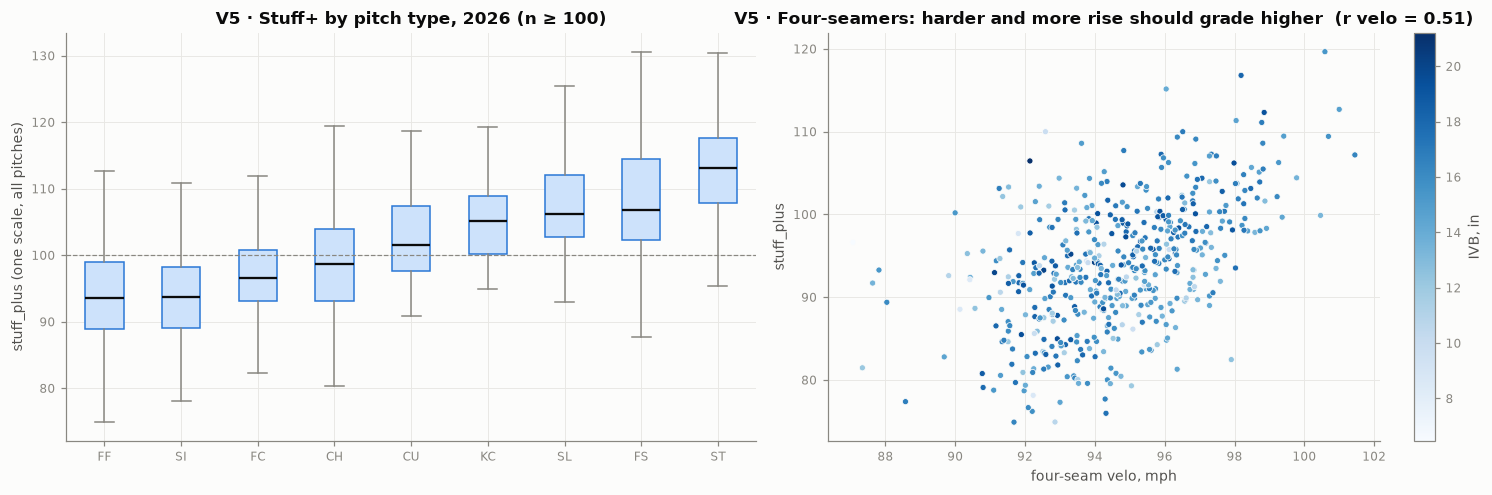

In [21]:
# V5 — common-sense checks: Stuff+ spread by pitch type, and fastball Stuff+ vs velo and rise
a26 = agg[agg.season == 2026]
order = a26.groupby("pitch_type").stuff_plus.median().sort_values().index
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].boxplot([a26.loc[a26.pitch_type == t, "stuff_plus"] for t in order], tick_labels=list(order), vert=True,
              widths=0.5, patch_artist=True, showfliers=False,
              boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE), medianprops=dict(color=INK, lw=1.5),
              whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax[0].axhline(100, color=MUTED, lw=0.8, ls="--")
ax[0].set(ylabel="stuff_plus (one scale, all pitches)", title="V5 · Stuff+ by pitch type, 2026 (n ≥ 100)")
ff = a26[a26.pitch_type == "FF"]
sc = ax[1].scatter(ff.velo, ff.stuff_plus, c=ff.ivb, cmap="Blues", s=16, edgecolors=SURFACE, linewidths=0.5)
fig.colorbar(sc, ax=ax[1], label="IVB, in")
ax[1].set(xlabel="four-seam velo, mph", ylabel="stuff_plus",
          title=f"V5 · Four-seamers: harder and more rise should grade higher  (r velo = {ff.velo.corr(ff.stuff_plus):.2f})")
plt.tight_layout(); plt.show()

In [22]:
# 2026 leaderboard (test season, never seen in training or early stopping)
names = raw.drop_duplicates("pitcher").set_index("pitcher").player_name
top = a26.assign(name=lambda d: d.pitcher.map(names))
top.sort_values("stuff_plus", ascending=False).head(15)[["name", "pitch_type", "n", "velo", "ivb", "stuff_plus", "stuff_plus_type", "actual"]].astype({"velo": float, "ivb": float, "stuff_plus": float, "stuff_plus_type": float, "actual": float}).round(1)

,name,pitch_type,n,velo,ivb,stuff_plus,stuff_plus_type,actual
24719,"Sasaki, Roki",FS,765,89.2,0.4,138.7,129.8,0.6
24259,"Misiorowski, Jacob",SL,297,91.8,1.7,137.8,141.4,1.7
21910,"Megill, Trevor",KC,309,88.0,-2.1,132.8,133.4,2.9
21039,"Chapman, Aroldis",FS,103,90.2,3.0,130.6,121.8,3.1
22662,"Bender, Anthony",ST,279,83.5,3.0,130.4,124.7,3.4
24670,"Garcia, Brandyn",ST,213,87.7,4.2,130.2,124.6,3.4
24528,"Yesavage, Trey",FS,470,82.9,6.7,130.0,121.2,0.5
22769,"Morejon, Adrian",SL,200,89.4,-0.5,129.4,129.8,-1.3
22034,"Duran, Jhoan",ST,103,89.5,-0.8,129.4,123.4,3.6
22819,"Smith, Cade",FS,309,87.1,-5.2,129.0,120.2,2.2


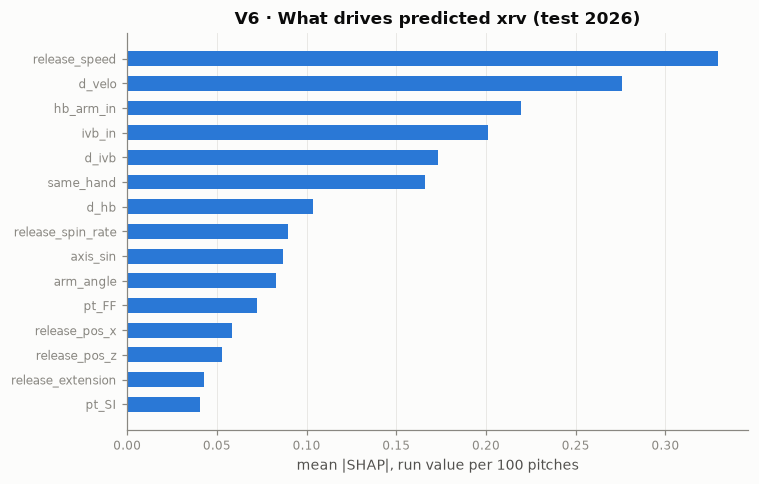

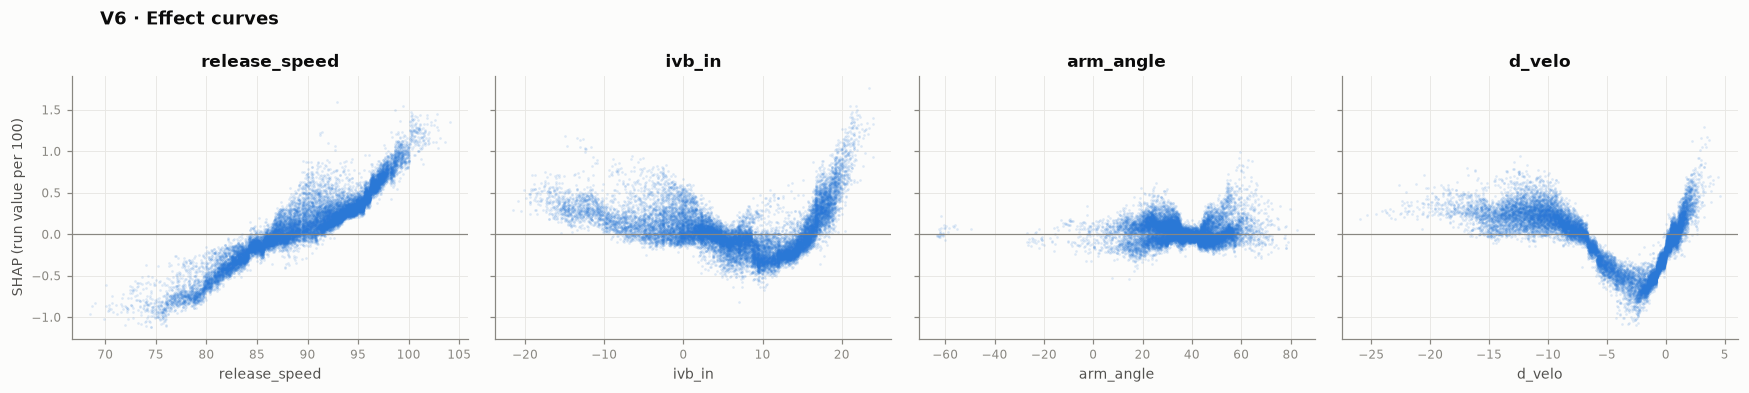

In [23]:
# V6 — what the model learned (SHAP on a 2026 sample): summary + effect curves for the physics that should matter
# xgboost computes exact TreeSHAP itself (pred_contribs) — no shap package needed; last column is the bias term
sample = X[te].sample(20_000, random_state=0)
shap_values = booster.get_booster().predict(xgb.DMatrix(sample), pred_contribs=True)[:, :-1]
imp = pd.Series(np.abs(shap_values).mean(0) * 100, index=FEATS).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.grid(axis="y", visible=False)
ax.set(xlabel="mean |SHAP|, run value per 100 pitches", title="V6 · What drives predicted xrv (test 2026)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for a_, f in zip(ax, ["release_speed", "ivb_in", "arm_angle", "d_velo"]):
    j = FEATS.index(f)
    ok = sample[f].notna().values
    a_.scatter(sample[f].values[ok], shap_values[ok, j] * 100, s=3, alpha=.15, color=BLUE, linewidths=0)
    a_.axhline(0, color=MUTED, lw=0.8)
    a_.set(xlabel=f, title=f)
ax[0].set_ylabel("SHAP (run value per 100)")
plt.suptitle("V6 · Effect curves", x=0.06, ha="left", fontweight="bold"); plt.tight_layout(); plt.show()

## 8. Findings (dry run on the full 2020–2026 data, 2026-10-05)

| Check | Result | Verdict |
|---|---|---|
| Cleaning | 4,500,123 of 4,548,695 pitches kept (98.9%) | clean |
| 2020 per-pitch R², with vs without arm angle | 0.00278 vs 0.00271 | missing arm angle barely hurts |
| XGBoost vs Ridge vs velo + type, forecasting 2026 RV/100 | 0.184 vs 0.085 vs 0.066 | beats simple physics rules |
| **XGBoost vs 2025 CSW% (V3)** | **0.184 vs 0.186**, difference −0.002, 95% CI [−0.066, +0.061] | **tie: a one-line stat matches the model over a full season** |
| **Early read (V8): first k pitches of 2026 → rest of season** | k=25: Stuff 0.118 vs CSW% 0.133 · k=50: 0.118 vs 0.168 · k=100: 0.169 vs 0.178 · k=200: 0.133 vs 0.200 | **CSW% wins at every k: the "Stuff reads faster" claim does not hold for this baseline model** |
| Target: xrv vs actual rv, four season pairs (V3b) | 2–2, mean difference +0.009 for actual | tie; **xrv kept** (it strips defense and luck, and the evidence doesn't reject it) |
| Stuff year-over-year (2025 → 2026) | 0.921 | very stable |
| Split-half reliability (V4) | stuff 0.96 at 25 pitches; whiff 0.5 at 50; actual RV/100 only 0.20 at 400 | Stuff is *stable* early, but V8 shows stable ≠ predictive: it is stable partly because physics barely changes |
| Site cutoff | `MIN_PITCHES_RV = 50` gates `whiff_pct` | in `statcast.py` |
| Pitcher-level calibration (V1) | top decile over-predicts (1.22 vs 0.88 xrv per 100) | shrink toward the mean next phase |
| Physics sanity (V5, V6) | four-seam Stuff+ vs velo r = 0.51; high ride good, ~10" IVB a dead zone; 2–5 mph off the fastball worst | textbook |
| Top SHAP drivers | velo, Δvelo from fastball, horizontal break, IVB, ΔIVB, same-hand | |

**Why CSW% wins, and what that means:** CSW% counts called strikes, so it carries location and command; this model is
physics only by design. Stuff is very stable (V4) but explains little of what happens next. The baseline model has
not yet earned a place next to CSW% for decision-making.

Next, ranked by what would change that verdict:
1. Stuff + CSW% blend weighted by sample size; test on V3 and V8.
2. A location + count Pitching+ variant (the like-for-like comparison with CSW%).
3. Shrinkage for pitcher-level Stuff (V1 over-predicts the top decile).
4. Per-pitch-type models (fastballs / breaking / offspeed); slider and sweeper merged into one family.
5. `stuff_plus` / `stuff_plus_type` to `pitch_arsenal` (migration 0012), only after 1–2 show it adds signal.
